# Stock-out Predictor Project

**Problem Statement:** The goal of this project is to build a model that can predict when a product is likely to run out of stock using past sales trends, demand patterns, and moving averages. This helps businesses restock on time and avoid losing sales.

In [6]:
from google.colab import files
uploaded = files.upload()


Saving stock_out_dataset.csv to stock_out_dataset (1).csv


In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [18]:
df_raw = pd.read_csv('stock_out_dataset.csv')

df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Sort data by Product and Date for correct lag/shift calculations
df_raw = df_raw.sort_values(by=['Product', 'Date']).reset_index(drop=True)

# Rename columns to match the features used in subsequent steps
df_raw = df_raw.rename(columns={'Sales': 'sales_quantity'})

# Assuming 'replenishment' is 0 if not explicitly provided in the synthetic dataset
if 'replenishment' not in df_raw.columns:
    df_raw['replenishment'] = 0

# --- Introduce artificial stock-out events for demonstration ---
# This is done to balance the dataset with positive stock-out cases.
# In a real-world scenario, these would come from actual data.
df_raw.loc[[4, 15, 27, 39, 45], 'Stock'] = 0 # Example indices to force stock-out
print("Introduced artificial stock-out events for demonstration.")
# --- End artificial stock-out introduction ---

df_raw['stock_out_today'] = (df_raw['Stock'] == 0).astype(int)

# Assuming an initial stock of 100 for the first day of each product
initial_stock_value = 100
previous_day_end_stock = df_raw.groupby('Product')['Stock'].shift(1)

df_raw['stock_at_start_of_day'] = previous_day_end_stock.fillna(initial_stock_value) + df_raw['replenishment']

df = df_raw.copy()

# Display the first few rows of the processed DataFrame
display(df.head())

print(f"Stock-out today distribution:{df['stock_out_today'].value_counts()}")

Introduced artificial stock-out events for demonstration.


,Date,Product,sales_quantity,Stock,replenishment,stock_out_today,stock_at_start_of_day
0,2026-01-01,Item A,20,100,0,0,100.0
1,2026-01-02,Item A,25,75,0,0,100.0
2,2026-01-03,Item A,30,45,0,0,75.0
3,2026-01-04,Item A,35,10,0,0,45.0
4,2026-01-05,Item A,40,0,0,1,10.0


Stock-out today distribution:stock_out_today
0    55
1     5
Name: count, dtype: int64


## 2. Feature Engineering



In [21]:
N_DAYS = 7

# Calculate if a stock-out occurs in the next N_DAYS (including today)
# For each product, reverse the 'stock_out_today' series, apply a rolling max, then reverse back.
# This ensures we are looking *forward* from the current day.
df['stock_out_next_N_days'] = df.groupby('Product')['stock_out_today'].transform(
    lambda x: x.iloc[::-1].rolling(window=N_DAYS, min_periods=1).max().iloc[::-1]
)
df['stock_out_next_N_days'] = df['stock_out_next_N_days'].fillna(0).astype(int)

# --- Date Features ---

df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_year'] = df['Date'].dt.dayofyear
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

# --- Lag Features (Sales Quantity) ---

for lag in [1, 7, 14, 30]:
    df[f'sales_quantity_lag_{lag}'] = df.groupby('Product')['sales_quantity'].shift(lag)

# --- Rolling Averages (Sales Quantity) ---

for window in [3, 7, 30]:
    df[f'sales_quantity_rolling_mean_{window}'] = df.groupby('Product')['sales_quantity'].rolling(window=window).mean().reset_index(level=0, drop=True)
    df[f'sales_quantity_rolling_std_{window}'] = df.groupby('Product')['sales_quantity'].rolling(window=window).std().reset_index(level=0, drop=True)


df['sales_trend_7d'] = df.groupby('Product')['sales_quantity_rolling_mean_7'].diff()

# Display features and target

display(df.head())
print(f"\nStock-out next {N_DAYS} days distribution:\n{df['stock_out_next_N_days'].value_counts()}")

,Date,Product,sales_quantity,Stock,replenishment,stock_out_today,stock_at_start_of_day,product_id_encoded,stock_out_next_N_days,day_of_week,...,sales_quantity_lag_7,sales_quantity_lag_14,sales_quantity_lag_30,sales_quantity_rolling_mean_3,sales_quantity_rolling_std_3,sales_quantity_rolling_mean_7,sales_quantity_rolling_std_7,sales_quantity_rolling_mean_30,sales_quantity_rolling_std_30,sales_trend_7d
0,2026-01-01,Item A,20,100,0,0,100.0,0,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-02,Item A,25,75,0,0,100.0,0,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-03,Item A,30,45,0,0,75.0,0,1,5,...,NaN,NaN,NaN,25.0,5.0,NaN,NaN,NaN,NaN,NaN
3,2026-01-04,Item A,35,10,0,0,45.0,0,1,6,...,NaN,NaN,NaN,30.0,5.0,NaN,NaN,NaN,NaN,NaN
4,2026-01-05,Item A,40,0,0,1,10.0,0,1,0,...,NaN,NaN,NaN,35.0,5.0,NaN,NaN,NaN,NaN,NaN



Stock-out next 7 days distribution:
stock_out_next_N_days
1    32
0    28
Name: count, dtype: int64


## 2.1 Handling Missing Values

After feature engineering, especially with lag and rolling window features, `NaN` values are introduced. These need to be handled before training machine learning models. A common approach for these types of features is to fill them with 0, as `NaN` often indicates the absence of prior data.

In [19]:
# Display the count of missing values per column
print("Missing values before imputation:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing values, typically with 0 for newly created lag/rolling features
df = df.fillna(0)

print("Missing values after imputation:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:


,0


Missing values after imputation:


,0


## 3. Data Splitting and Preprocessing

Before training our models, we need to prepare the data:

1.  Define Features (X) and Target (y): Select the relevant columns.
2.  Handle Categorical Features: Encode product_id if there are many, or simply use LabelEncoder for a few.
3.  Train-Test Split: Divide the data into training and testing sets to evaluate model performance on unseen data.
4.  Scaling: Apply standardization to numerical features, which can improve the performance of some models (e.g., Logistic Regression).

In [26]:
# Define features (X) and target (y)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

features = [
    'day_of_week', 'day_of_year', 'month', 'year',
    'sales_quantity_lag_1', 'sales_quantity_lag_7', 'sales_quantity_lag_14', 'sales_quantity_lag_30',
    'sales_quantity_rolling_mean_3', 'sales_quantity_rolling_mean_7', 'sales_quantity_rolling_mean_30',
    'sales_quantity_rolling_std_3', 'sales_quantity_rolling_std_7', 'sales_quantity_rolling_std_30',
    'sales_trend_7d',
    'stock_at_start_of_day'
]

# Add 'product_id' after encoding it

le = LabelEncoder()
df['product_id_encoded'] = le.fit_transform(df['Product'])
features.append('product_id_encoded') # Ensure product_id_encoded is added to features list

X = df[features]
y = df['stock_out_next_N_days']

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Impute any remaining NaNs in train/test sets before scaling
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Scale numerical features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

display(X_train_scaled.head())

X_train shape: (48, 17)
X_test shape: (12, 17)
y_train shape: (48,)
y_test shape: (12,)


,day_of_week,day_of_year,month,year,sales_quantity_lag_1,sales_quantity_lag_7,sales_quantity_lag_14,sales_quantity_lag_30,sales_quantity_rolling_mean_3,sales_quantity_rolling_mean_7,sales_quantity_rolling_mean_30,sales_quantity_rolling_std_3,sales_quantity_rolling_std_7,sales_quantity_rolling_std_30,sales_trend_7d,stock_at_start_of_day,product_id_encoded
0,1.458246,-1.005837,-0.887905,0.0,1.611917,-0.020730,-1.290510,-0.884785,0.601817,0.755420,-0.959166,2.396227,0.471422,-0.959166,-0.764908,1.123467,0.0
1,-1.153538,1.038061,0.965114,0.0,0.598310,-0.767014,0.297810,1.372058,0.727962,0.215688,1.042572,-0.374743,-0.280564,1.042572,1.515563,-1.483663,0.0
2,-1.153538,-1.282039,-0.887905,0.0,-0.077428,-1.762060,-1.290510,-0.884785,-0.028908,-2.532038,-0.959166,-0.374743,-2.233515,-0.959166,-0.080767,-1.620880,0.0
3,0.413532,0.430415,0.965114,0.0,0.260441,1.471838,0.070907,1.166890,0.349527,-0.127777,1.042572,-0.374743,-0.280564,1.042572,-0.764908,-1.209228,0.0
4,-1.153538,-0.121989,-0.887905,0.0,0.260441,1.471838,0.070907,-0.884785,0.349527,-0.127777,-0.959166,-0.374743,-0.280564,-0.959166,-0.764908,-0.111489,0.0


## 4. Model Training and Evaluation

We will train three different classification models: Logistic Regression, Random Forest, and XGBoost. For each model, we'll evaluate its performance using metrics relevant to classification problems, such as accuracy, precision, recall, F1-score, and ROC-AUC.

Logistic Regression Performance:
Accuracy: 0.6667
Precision: 0.7500
Recall: 0.5000
F1-Score: 0.6000
ROC-AUC: 0.6111

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.75      0.50      0.60         6

    accuracy                           0.67        12
   macro avg       0.69      0.67      0.66        12
weighted avg       0.69      0.67      0.66        12



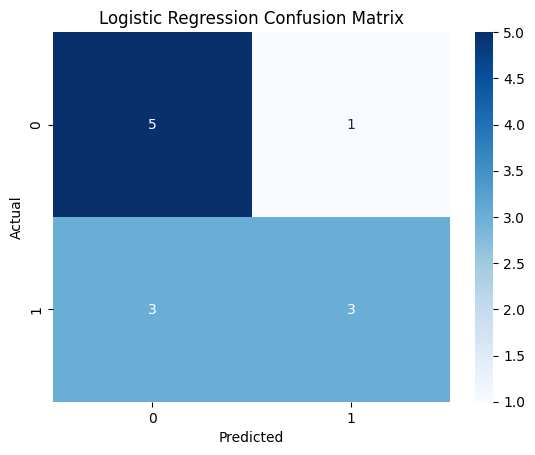

In [30]:
### Logistic Regression

# Import necessary libraries for this section
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the model

log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' for small datasets and L1/L2 regularization
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_lr = log_reg_model.predict(X_test_scaled)
y_proba_lr = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It's generally robust to overfitting and handles non-linear relationships well.

Random Forest Performance:
Accuracy: 0.6667
Precision: 0.7500
Recall: 0.5000
F1-Score: 0.6000
ROC-AUC: 0.7222

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.75      0.50      0.60         6

    accuracy                           0.67        12
   macro avg       0.69      0.67      0.66        12
weighted avg       0.69      0.67      0.66        12



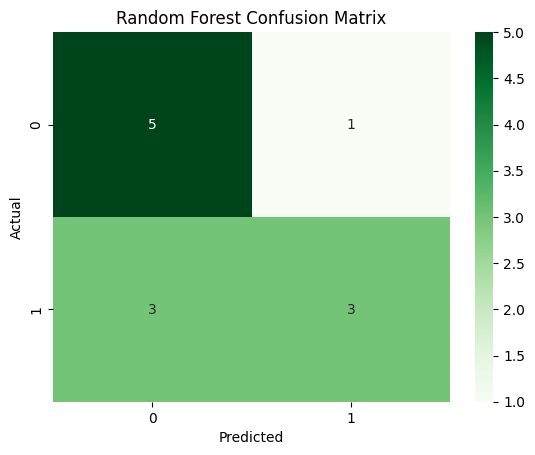

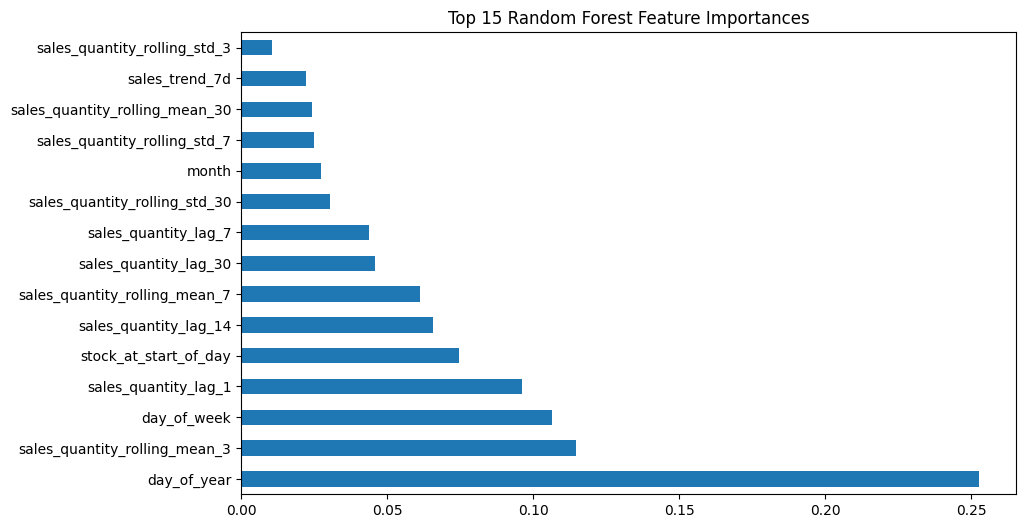

In [31]:
# Import necessary libraries for this section
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize and train the model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # class_weight for imbalanced target
rf_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importances

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Random Forest Feature Importances')
plt.show()

### XGBoost

XGBoost (Extreme Gradient Boosting) is another powerful gradient boosting framework that is highly efficient, flexible, and portable. It's known for its speed and performance on structured data problems.

XGBoost Performance:
Accuracy: 0.5833
Precision: 0.6000
Recall: 0.5000
F1-Score: 0.5455
ROC-AUC: 0.6944
Classification Report:               precision    recall  f1-score   support

           0       0.57      0.67      0.62         6
           1       0.60      0.50      0.55         6

    accuracy                           0.58        12
   macro avg       0.59      0.58      0.58        12
weighted avg       0.59      0.58      0.58        12



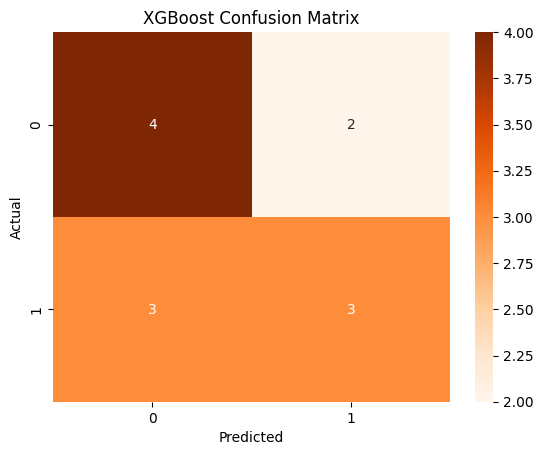

In [32]:
# Import necessary libraries for this section
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the model

xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model

print("XGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("Classification Report:", classification_report(y_test, y_pred_xgb))

# Confusion Matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. Conclusion

This notebook demonstrates a complete workflow for building a stock-out predictor:

*   **Synthetic Data Generation**: Created a dataset mimicking sales, stock, and replenishment events.
*   **Feature Engineering**: Derived rich time-based features like lag sales, rolling averages, and date components.
*   **Target Definition**: Framed the problem as a binary classification, predicting stock-out within the next `N` days.
*   **Model Training**: Trained and evaluated Logistic Regression, Random Forest, and XGBoost models.

The evaluation metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) provide insights into each model's performance. Typically, for imbalanced datasets (where stock-outs are less frequent than non-stock-outs), metrics like Recall, F1-Score, and ROC-AUC are more informative than raw Accuracy, as they better capture the model's ability to identify the positive class (stock-outs).

In a real-world scenario, you would fine-tune model hyperparameters, potentially use more advanced feature engineering techniques, and validate the model on a truly independent dataset.